## QUEST: Quantifying Uncertainty for EnSemble Tree Models

In [1]:
import sys
sys.path.append("../")


In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("../datasets/Ovarian_patient_data 2.csv")

In [4]:
df.head()

,Timestamp,Age,BMI,Comorbidity,Symptom,CA125,CancerStage,Histopathology,PreviousTreatment,MenstrualHistory,...,RadiomicIntensity,RadiomicShape,DopplerVelocity,Parity,OralContraceptives,HormoneTherapy,MenarcheAge,MenopauseAge,RiskLabel,ProgressionProbability
0,2019-01-01 00:00:00,67.450712,27.468755,0,0,66.738329,0,serous,0,regular,...,57.572038,1.285647,1.948916,0,0,0,12.077803,54.947593,2,0.176654
1,2019-01-01 01:00:00,57.926035,27.736019,1,0,28.390526,1,clear cell,0,regular,...,44.385558,0.656970,3.589821,0,0,0,12.745908,46.864164,0,0.343371
2,2019-01-01 02:00:00,69.715328,22.285561,0,0,118.120787,3,clear cell,1,regular,...,35.711312,1.034179,3.625658,0,0,0,12.495603,55.757130,0,0.036907
3,2019-01-01 03:00:00,82.845448,31.315519,1,1,6.418598,0,serous,1,regular,...,49.922109,1.000078,1.108221,0,0,0,12.577276,50.462495,1,0.161943
4,2019-01-01 04:00:00,56.487699,17.056296,1,0,65.912779,1,mucinous,0,regular,...,43.547336,1.415819,1.030482,2,0,0,14.698884,58.628299,0,0.554210


In [5]:
df.shape

(200100, 34)

In [6]:
df.RiskLabel.value_counts()

RiskLabel
0    119965
1     40092
2     30068
3      9975
Name: count, dtype: int64

In [7]:
df.drop(["Timestamp"], axis =1, inplace=True)

In [8]:
for i in df.columns:
    data_types = i+":"+str(df[i].dtype)
    print(data_types)

Age:float64
BMI:float64
Comorbidity:int64
Symptom:int64
CA125:float64
CancerStage:int64
Histopathology:object
PreviousTreatment:int64
MenstrualHistory:object
Ethnicity:object
Smoking:int64
Alcohol:int64
Residence:object
SocioeconomicStatus:object
BRCA_Mutation:int64
GeneExpression:float64
SNP_Status:int64
DNAMethylation:float64
miRNA:float64
TumorSize:float64
TumorLocation:object
EnhancementPattern:float64
RadiomicTexture:float64
RadiomicIntensity:float64
RadiomicShape:float64
DopplerVelocity:float64
Parity:int64
OralContraceptives:int64
HormoneTherapy:int64
MenarcheAge:float64
MenopauseAge:float64
RiskLabel:int64
ProgressionProbability:float64


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le_MenstrualHistory = LabelEncoder()
le_Histopathology= LabelEncoder()
le_Ethnicity= LabelEncoder()
le_Residence= LabelEncoder()
le_SocioeconomicStatus= LabelEncoder()
le_TumorLocation= LabelEncoder()


In [11]:
df["MenstrualHistory"] = le_MenstrualHistory.fit_transform(df["MenstrualHistory"])
df["Histopathology"] = le_MenstrualHistory.fit_transform(df["Histopathology"])
df["Ethnicity"] = le_MenstrualHistory.fit_transform(df["Ethnicity"])
df["Residence"] = le_MenstrualHistory.fit_transform(df["Residence"])
df["SocioeconomicStatus"] = le_MenstrualHistory.fit_transform(df["SocioeconomicStatus"])
df["TumorLocation"] = le_MenstrualHistory.fit_transform(df["TumorLocation"])

In [12]:
from sklearn.model_selection import train_test_split
X = df.drop(["RiskLabel","ProgressionProbability"], axis = 1)
y = df[["RiskLabel"]]

from imblearn.combine import SMOTETomek

nm1 = SMOTETomek()
X_resample, y_resample = nm1.fit_resample(X,y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_resample,y_resample, test_size = 0.2, stratify=y_resample)

In [14]:

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)


/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=10, random_state=42)

In [15]:
class_names = ["No Risk", "Low Risk", "Medium Risk", "High Risk"]

In [16]:
import numpy as np

In [17]:
class_names = np.array(class_names)

In [18]:
feature_names = X_train.columns
print(feature_names)

Index(['Age', 'BMI', 'Comorbidity', 'Symptom', 'CA125', 'CancerStage',
       'Histopathology', 'PreviousTreatment', 'MenstrualHistory', 'Ethnicity',
       'Smoking', 'Alcohol', 'Residence', 'SocioeconomicStatus',
       'BRCA_Mutation', 'GeneExpression', 'SNP_Status', 'DNAMethylation',
       'miRNA', 'TumorSize', 'TumorLocation', 'EnhancementPattern',
       'RadiomicTexture', 'RadiomicIntensity', 'RadiomicShape',
       'DopplerVelocity', 'Parity', 'OralContraceptives', 'HormoneTherapy',
       'MenarcheAge', 'MenopauseAge'],
      dtype='object')


In [19]:
from sklearn.metrics import f1_score, confusion_matrix
y_pred = model.predict(X_test)
print(f1_score(y_pred, y_test, average="macro"))

0.5885813046031367


In [20]:
confusion_matrix(y_pred, y_test)

array([[16807,  7003,  5573,  2132],
       [ 3717, 10558,  4651,  2115],
       [ 2457,  3882, 11479,  1947],
       [  858,  2437,  2252, 17790]])

/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, bu


Explaining for class: No Risk


Sampling hypothesis space: 100%|██████████| 500/500 [12:28<00:00,  1.50s/it]


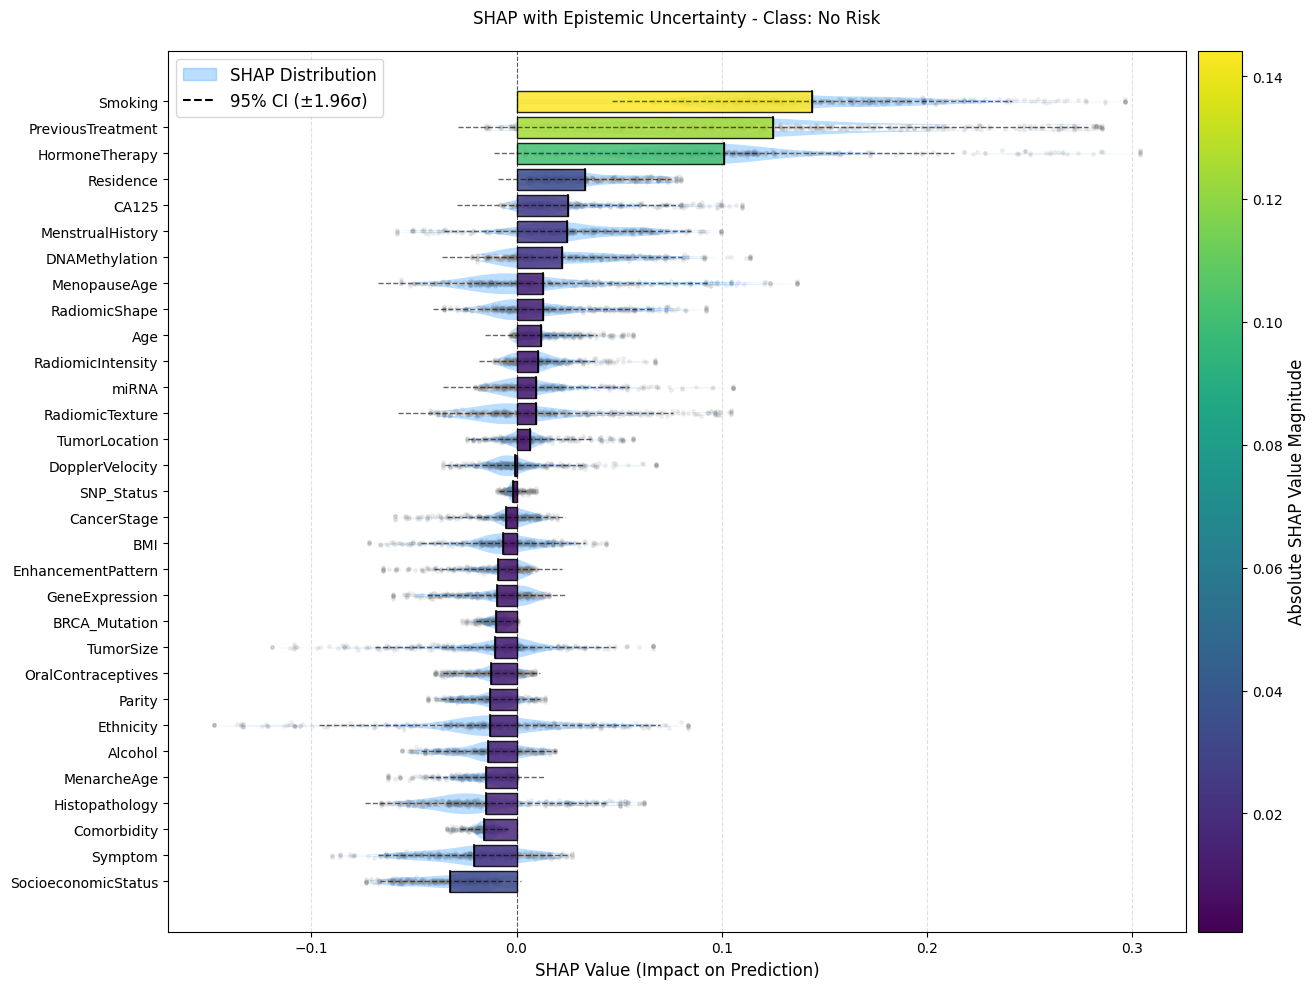

Top 5 indices: [13 12 28  7 10]


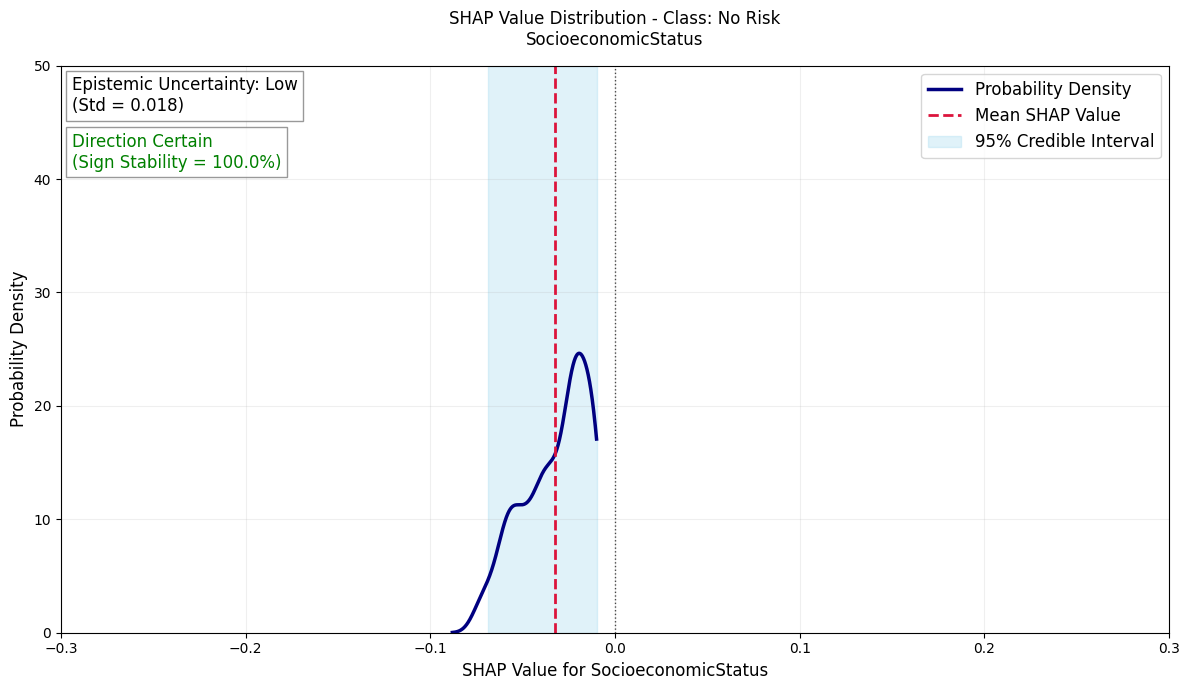

Top 5 indices: [13 12 28  7 10]


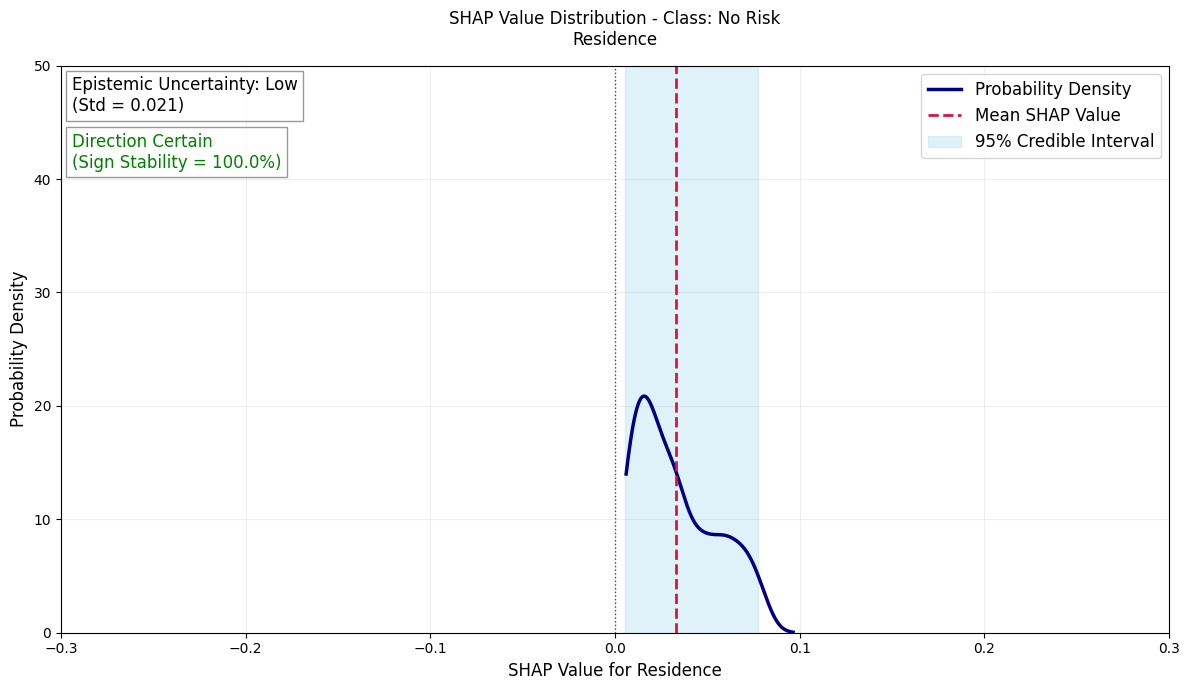

Top 5 indices: [13 12 28  7 10]


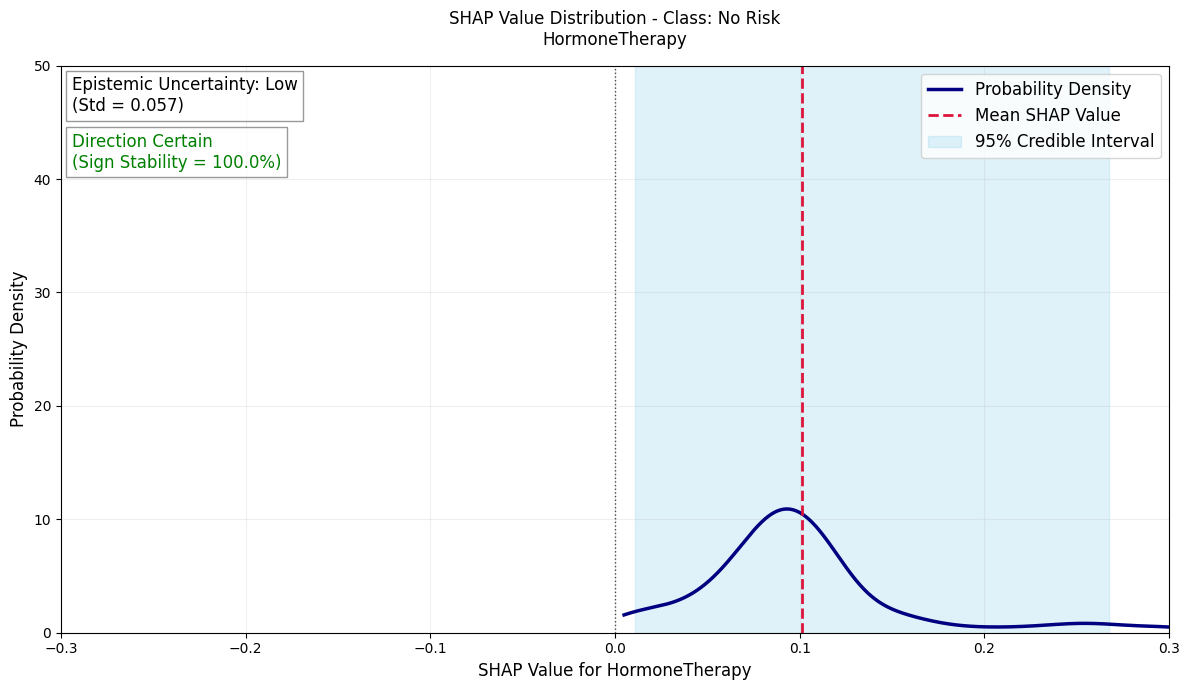

Top 5 indices: [13 12 28  7 10]


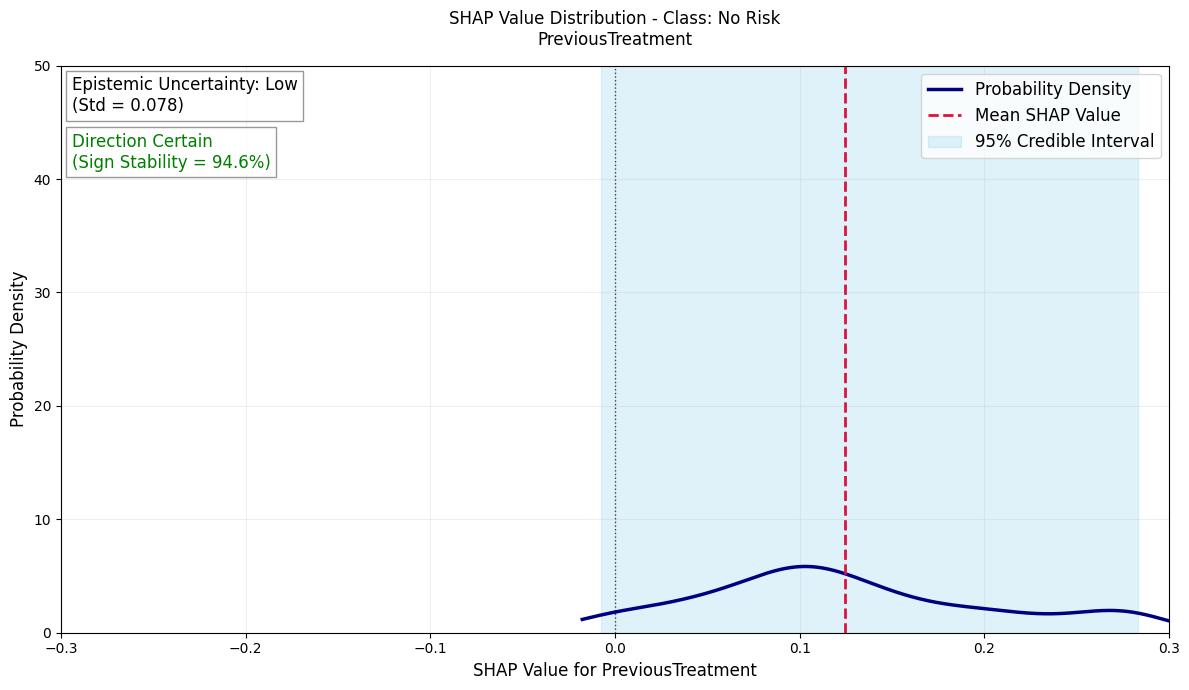

Top 5 indices: [13 12 28  7 10]


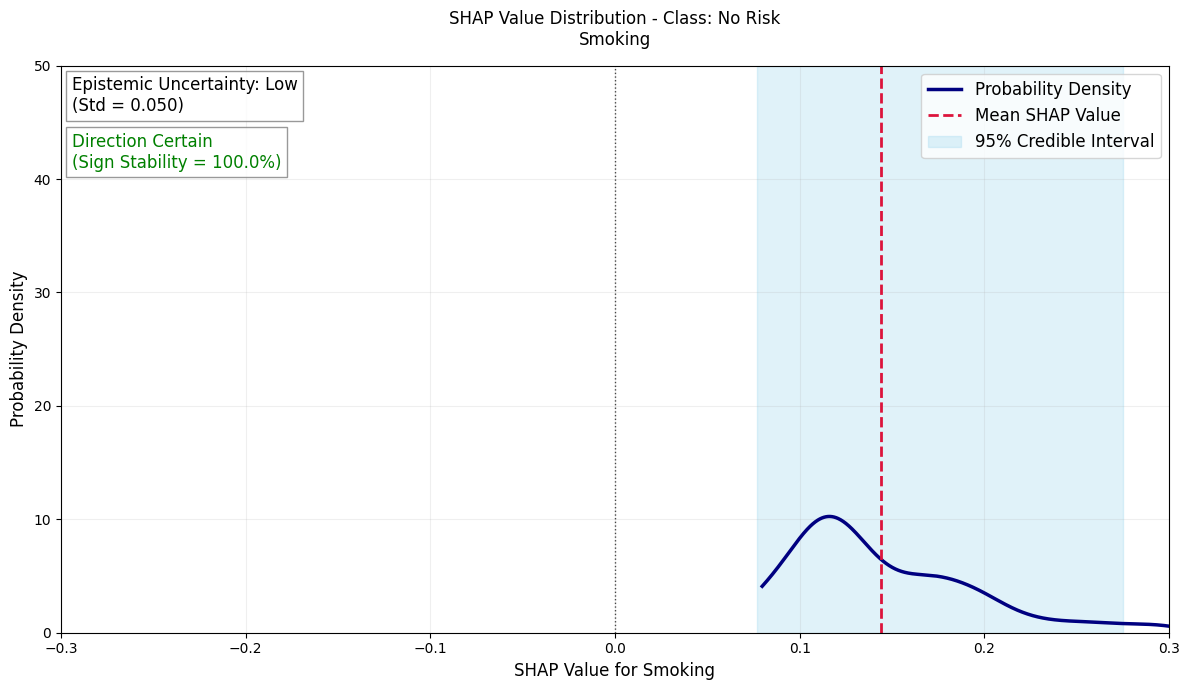

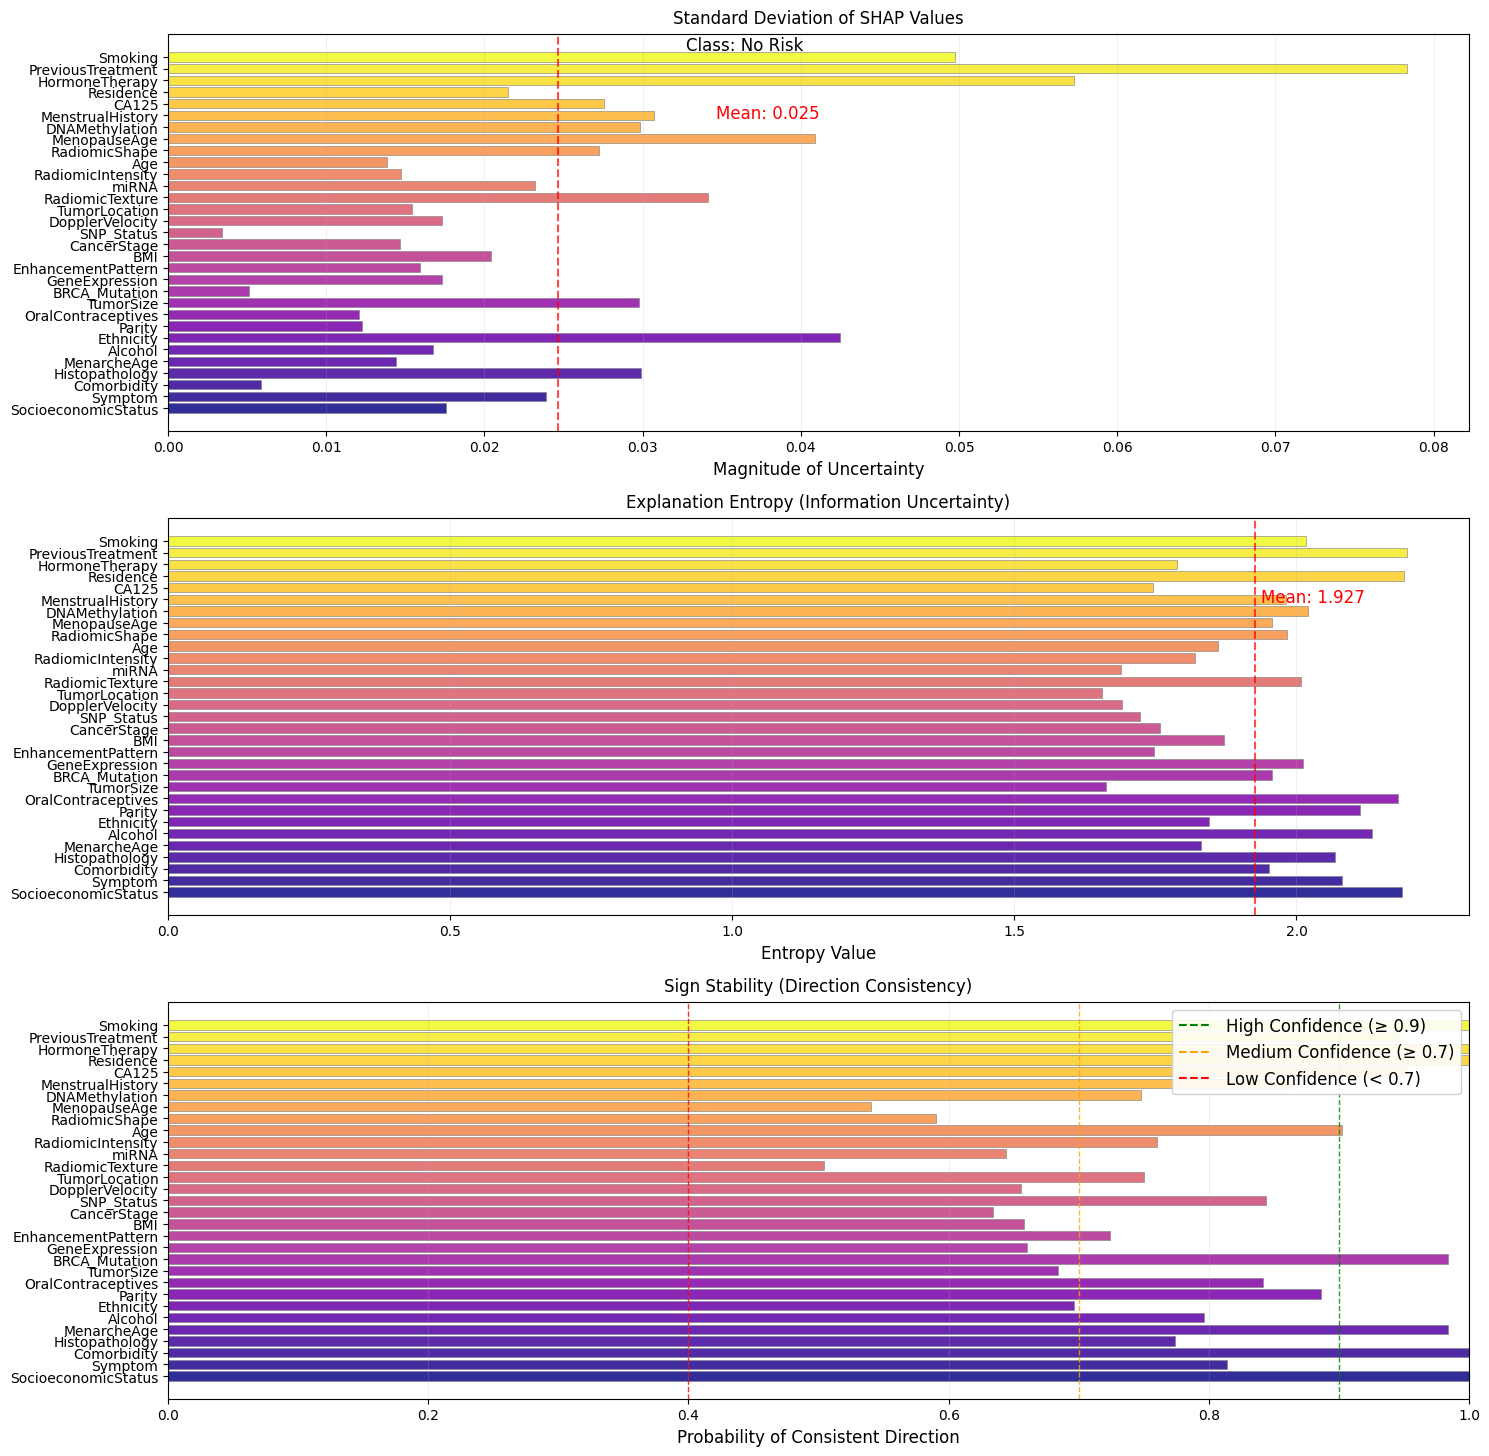


Explaining for class: Low Risk


Sampling hypothesis space: 100%|██████████| 500/500 [12:23<00:00,  1.49s/it]


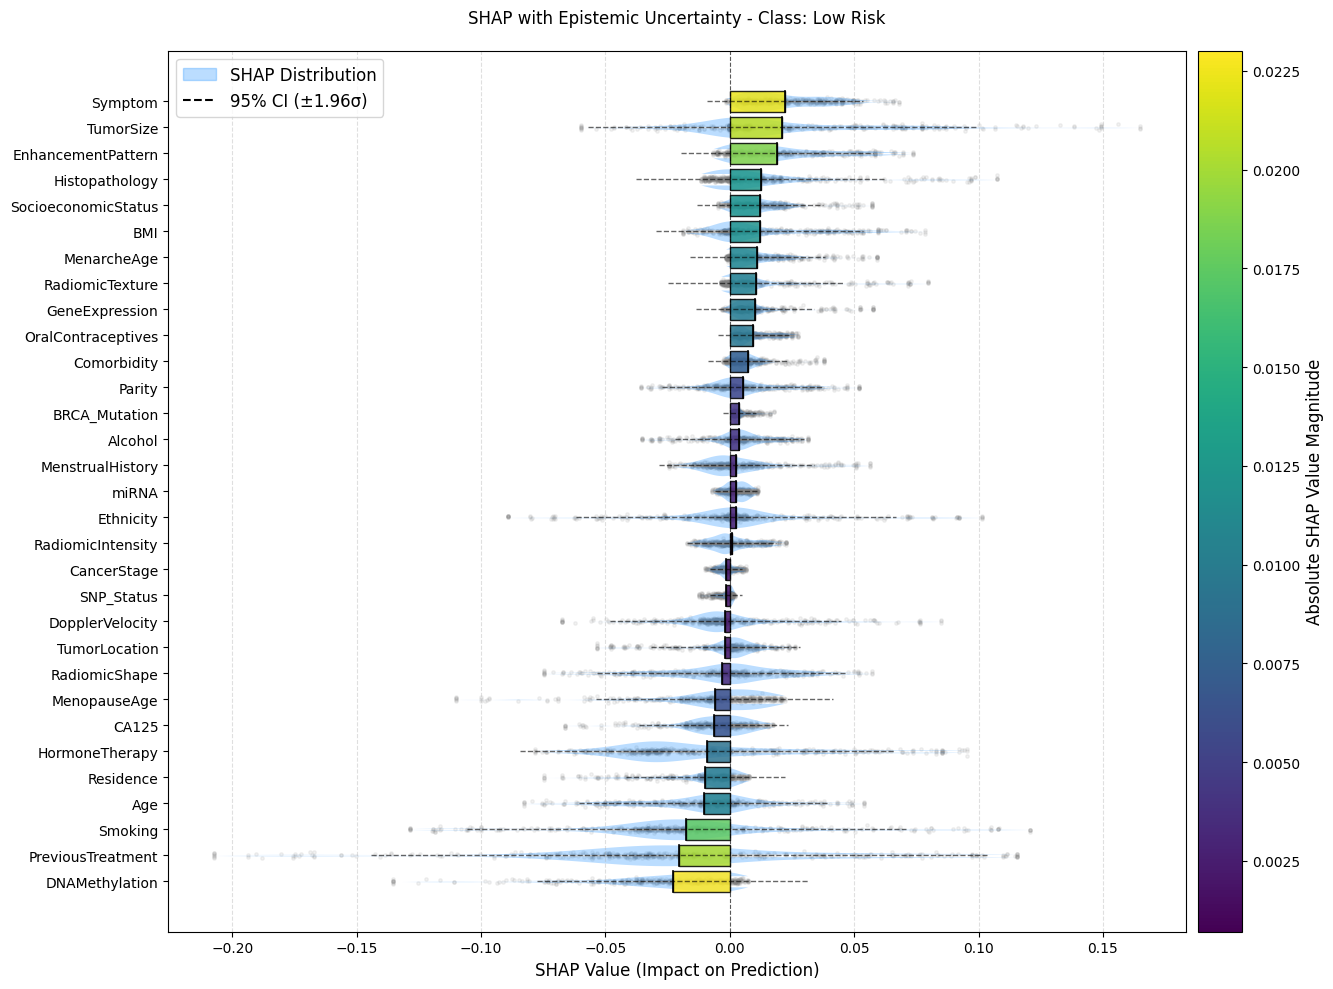

Top 5 indices: [21  7 19  3 17]


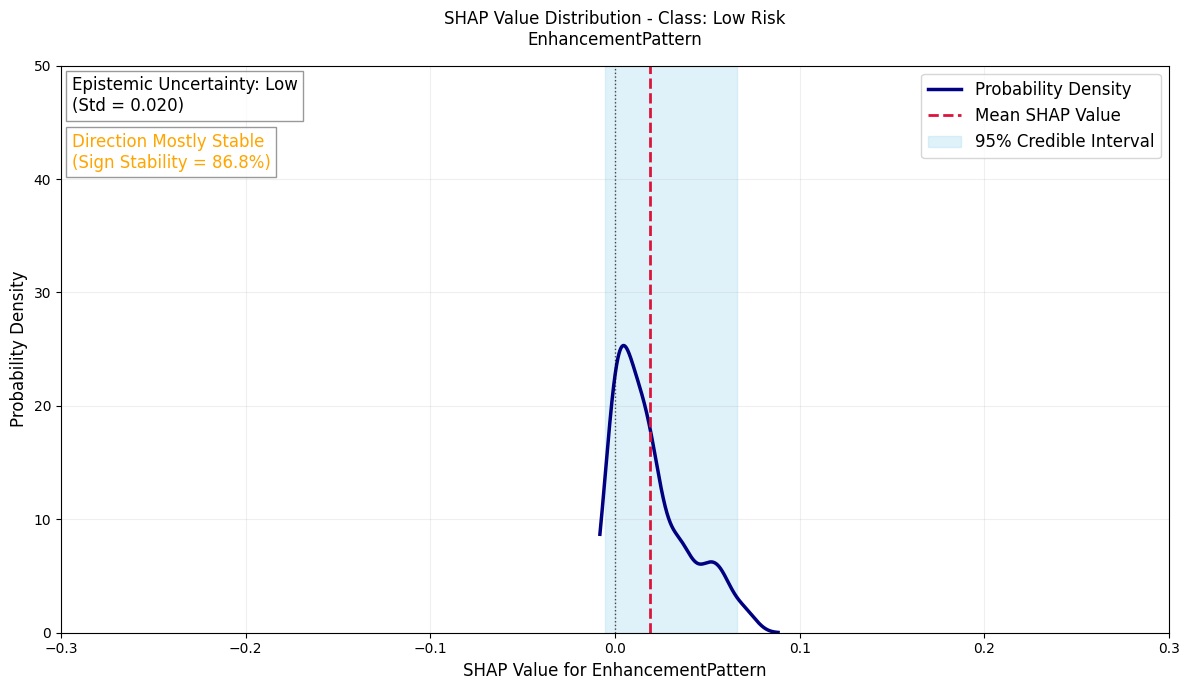

Top 5 indices: [21  7 19  3 17]


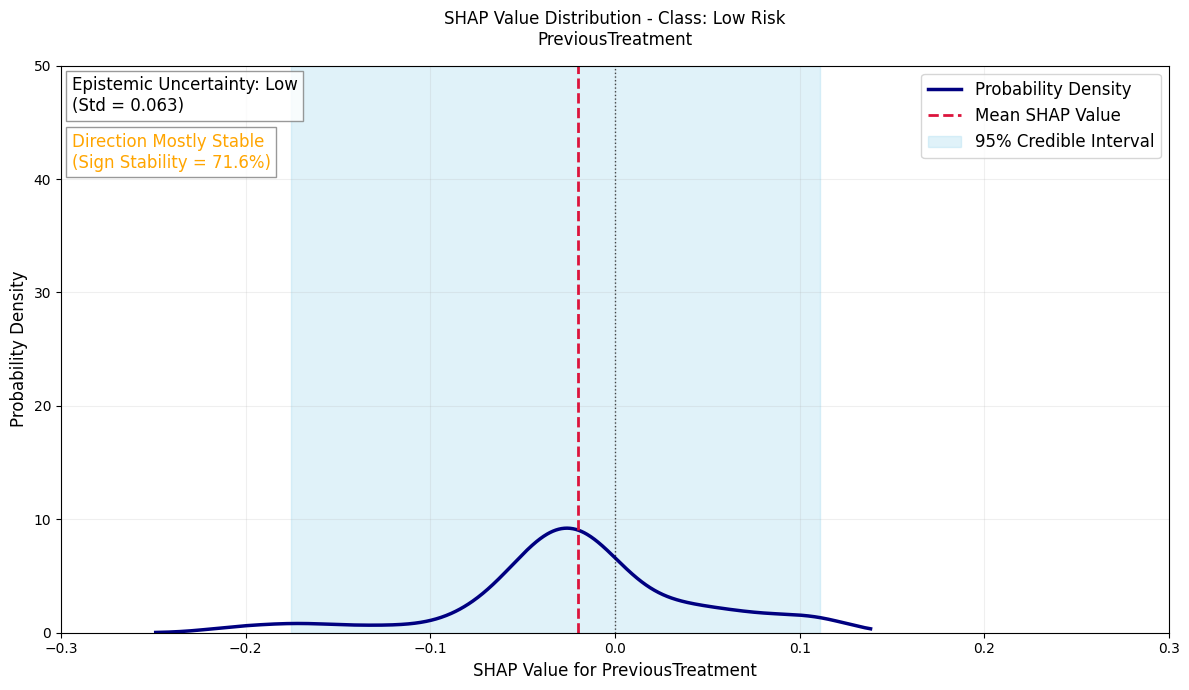

Top 5 indices: [21  7 19  3 17]


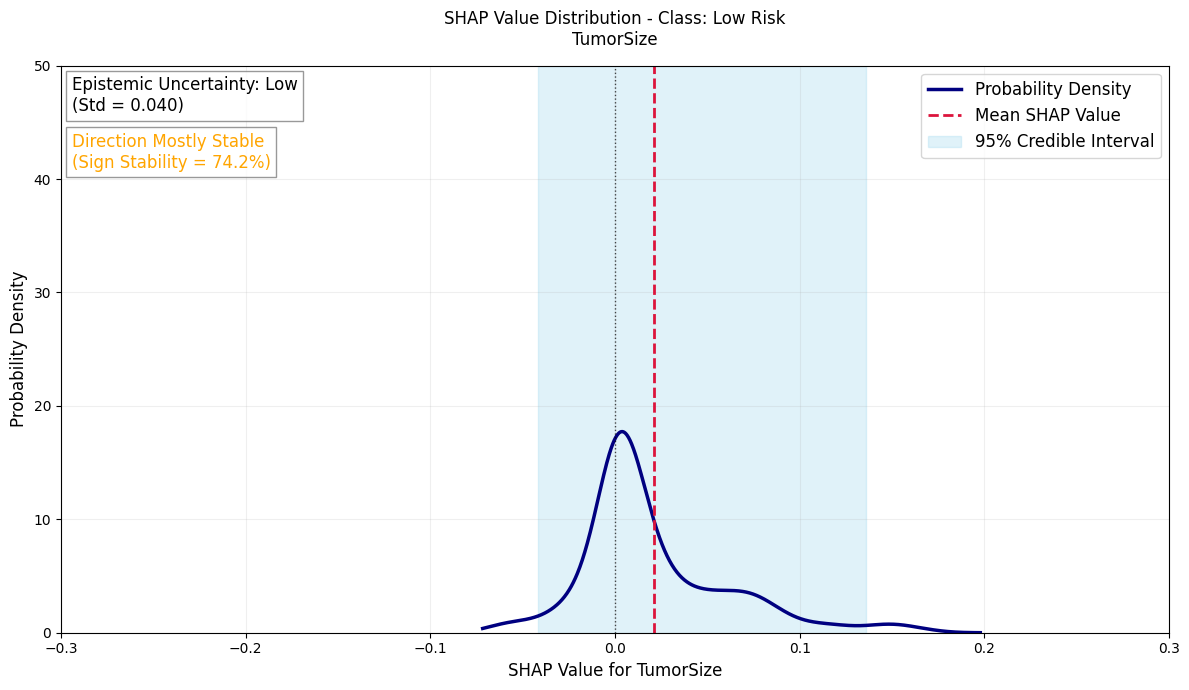

Top 5 indices: [21  7 19  3 17]


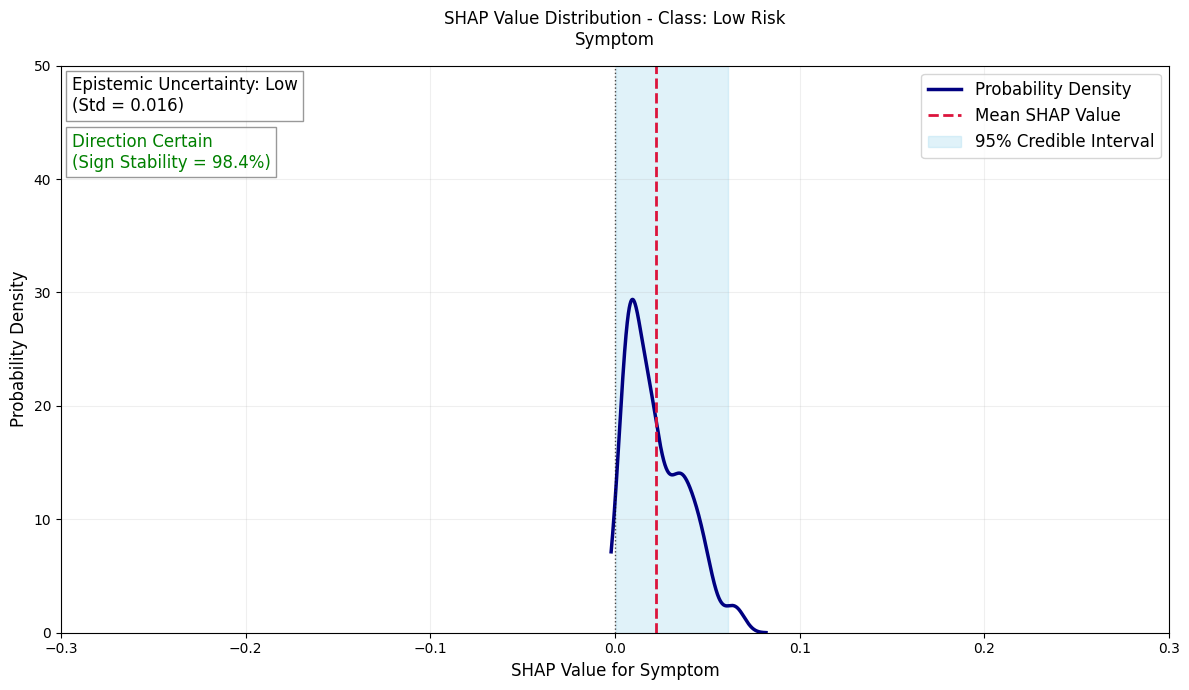

Top 5 indices: [21  7 19  3 17]


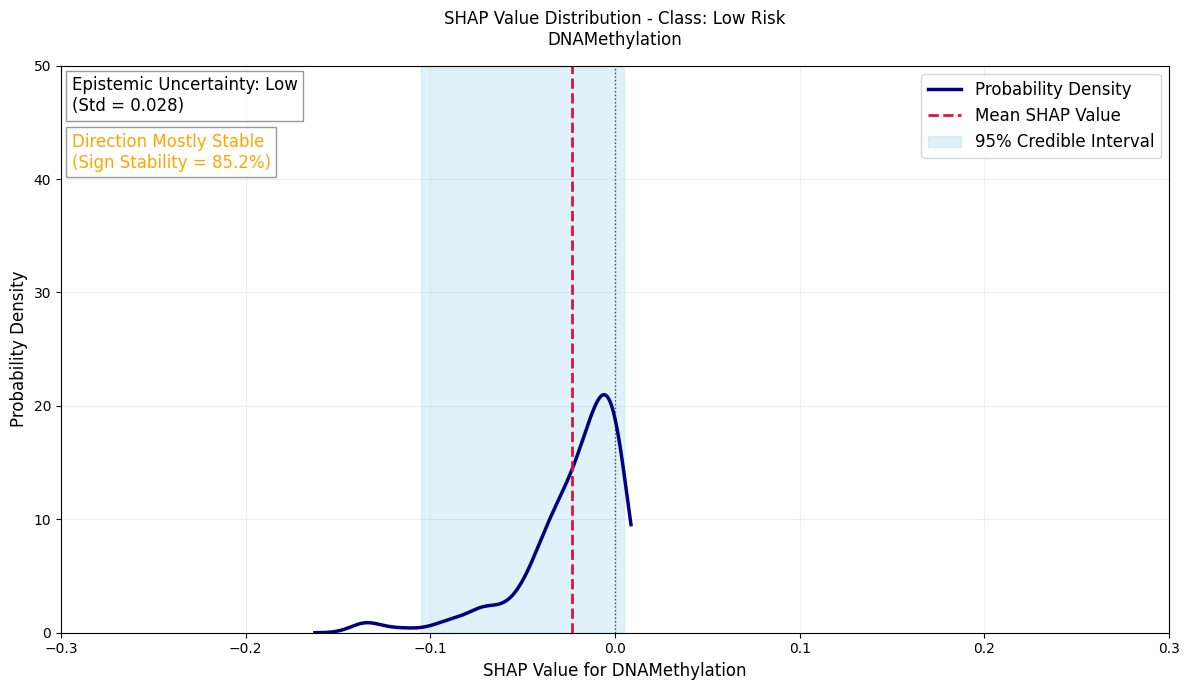

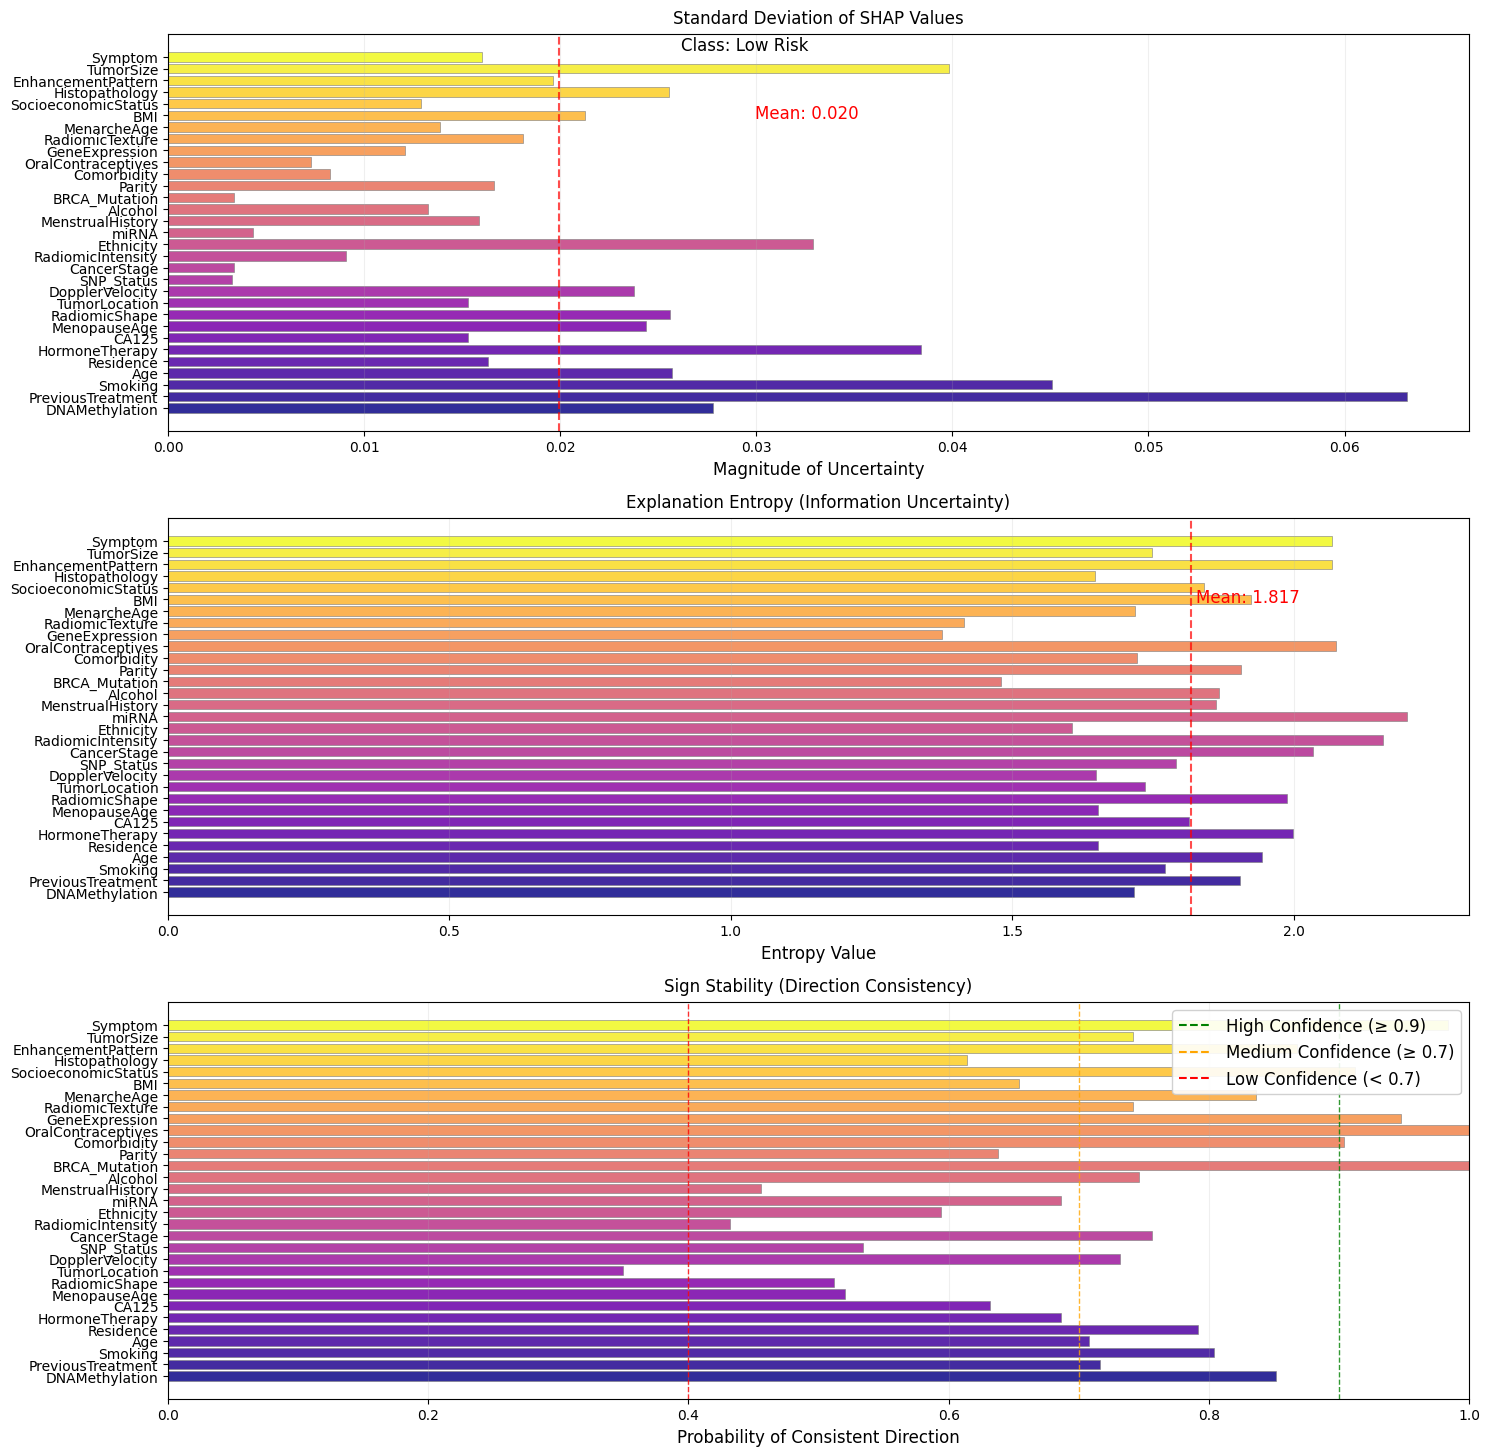


Explaining for class: Medium Risk


Sampling hypothesis space: 100%|██████████| 500/500 [12:24<00:00,  1.49s/it]


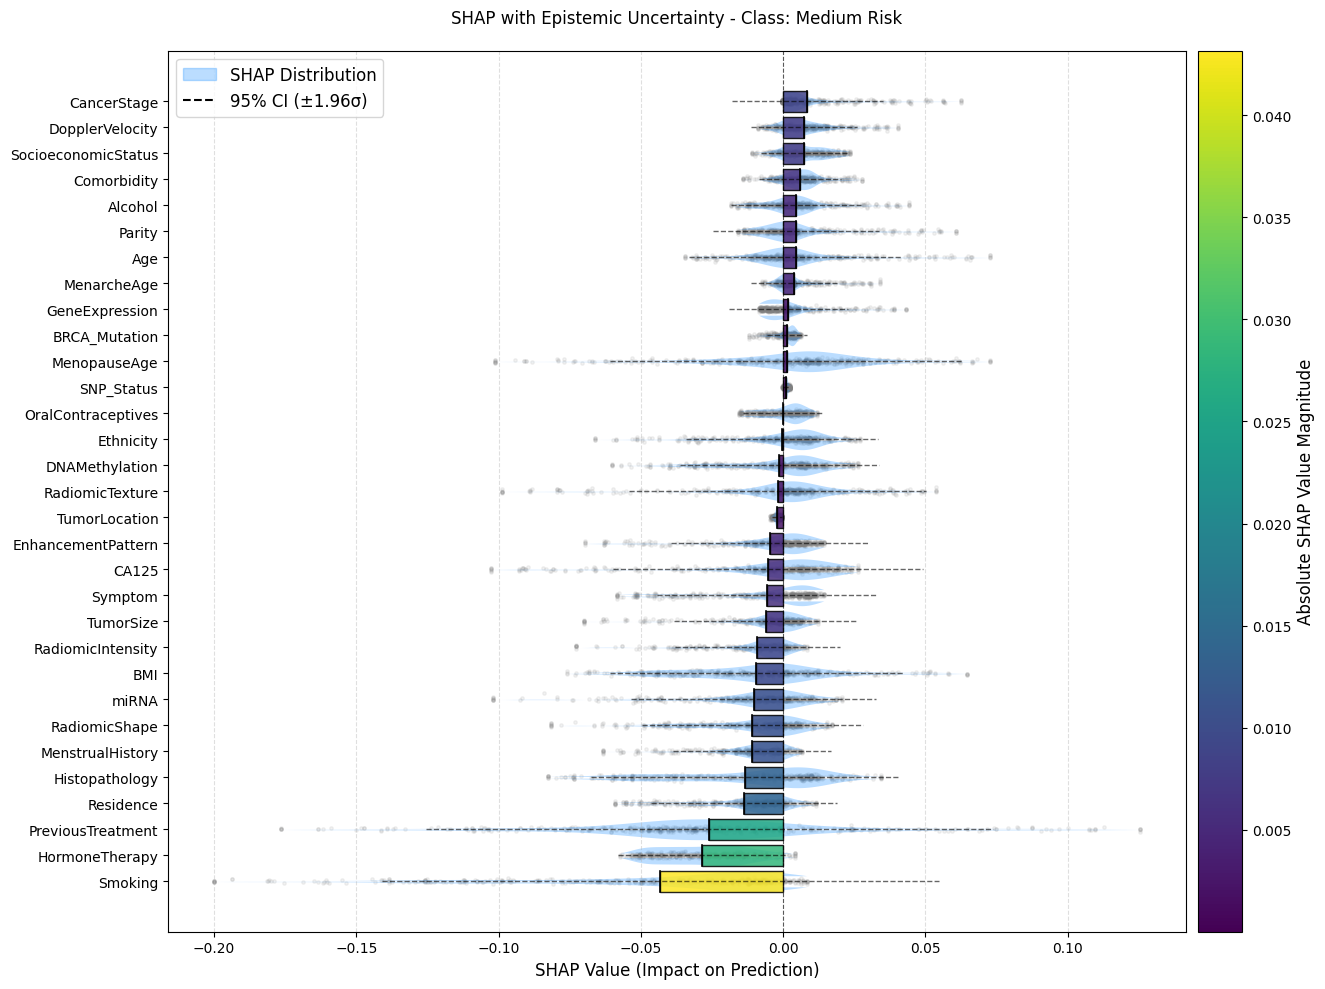

Top 5 indices: [ 6 12  7 28 10]


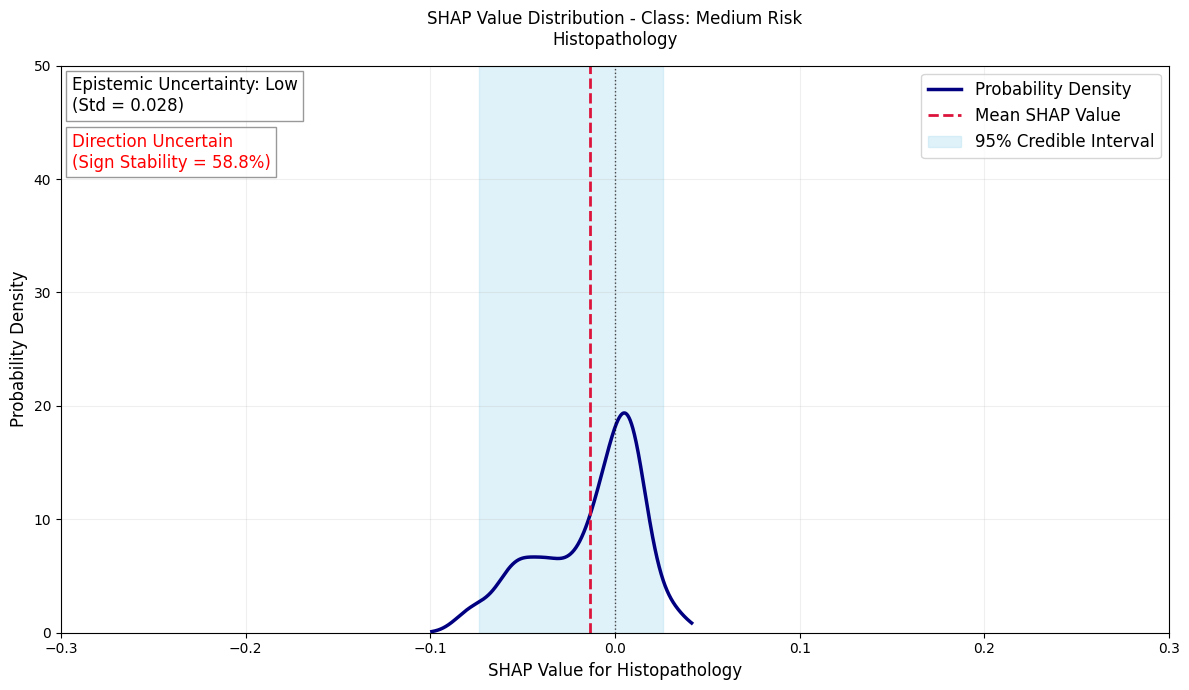

Top 5 indices: [ 6 12  7 28 10]


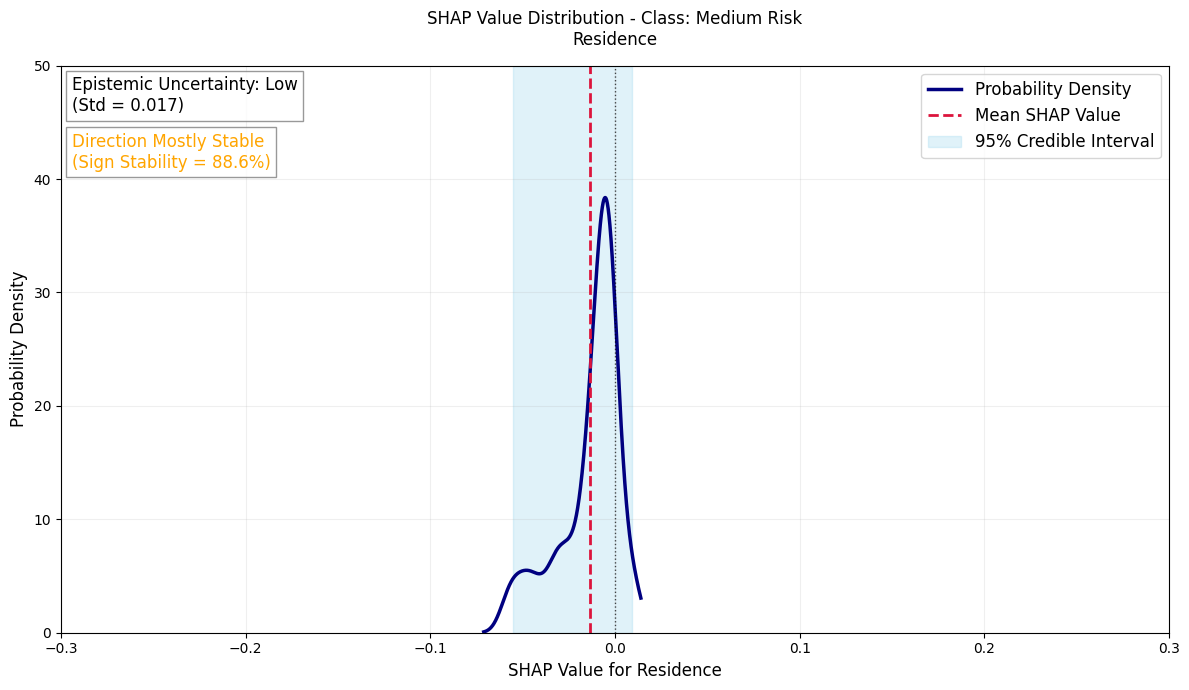

Top 5 indices: [ 6 12  7 28 10]


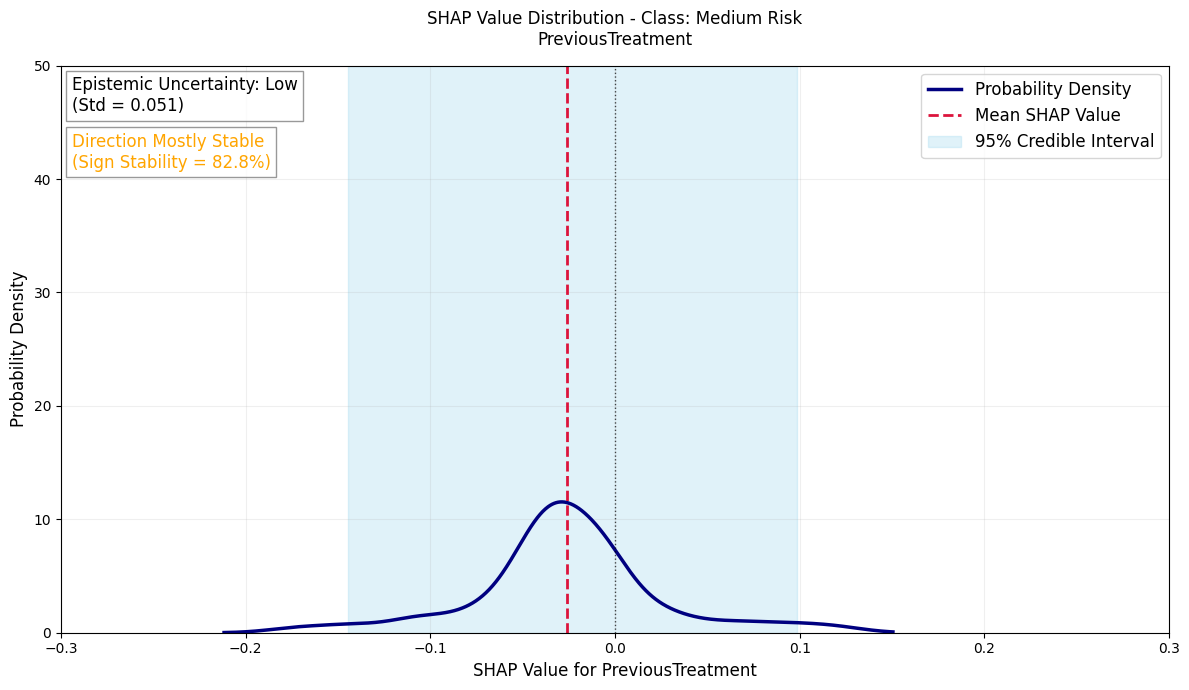

Top 5 indices: [ 6 12  7 28 10]


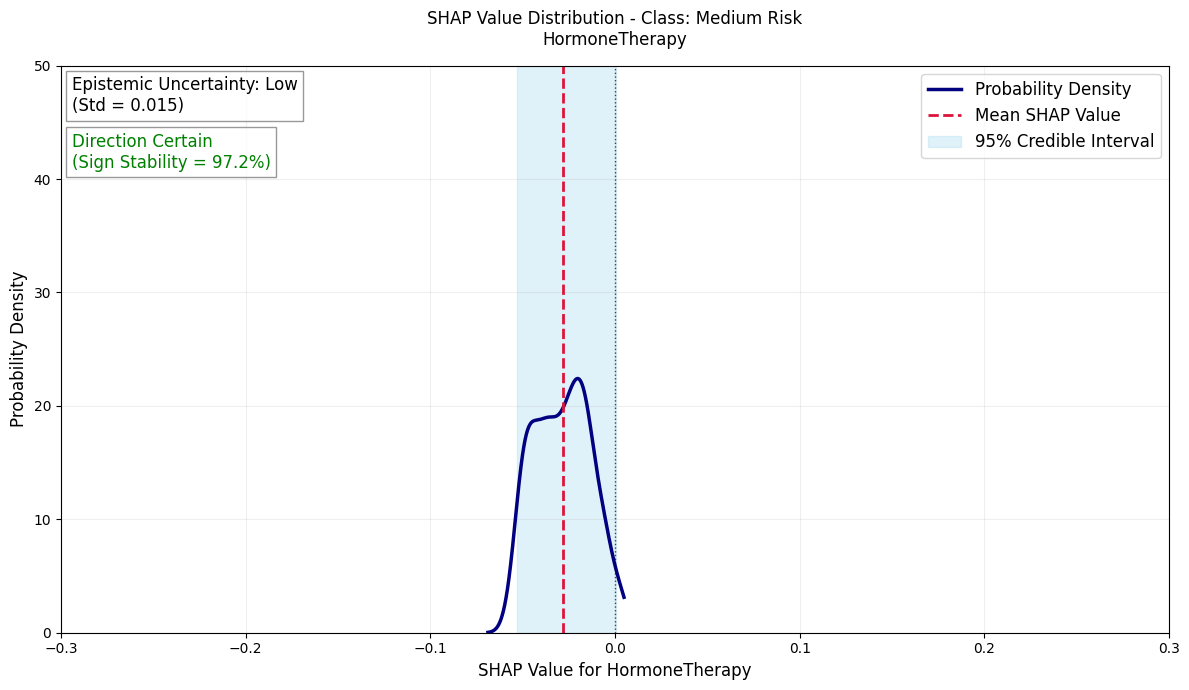

Top 5 indices: [ 6 12  7 28 10]


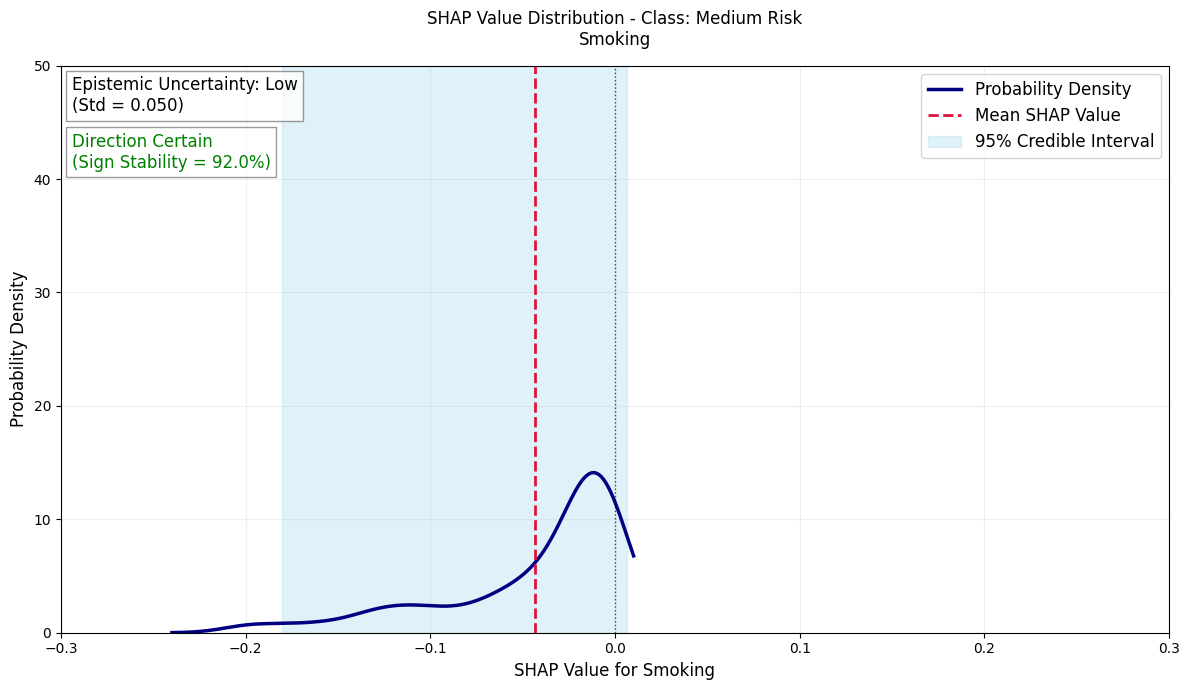

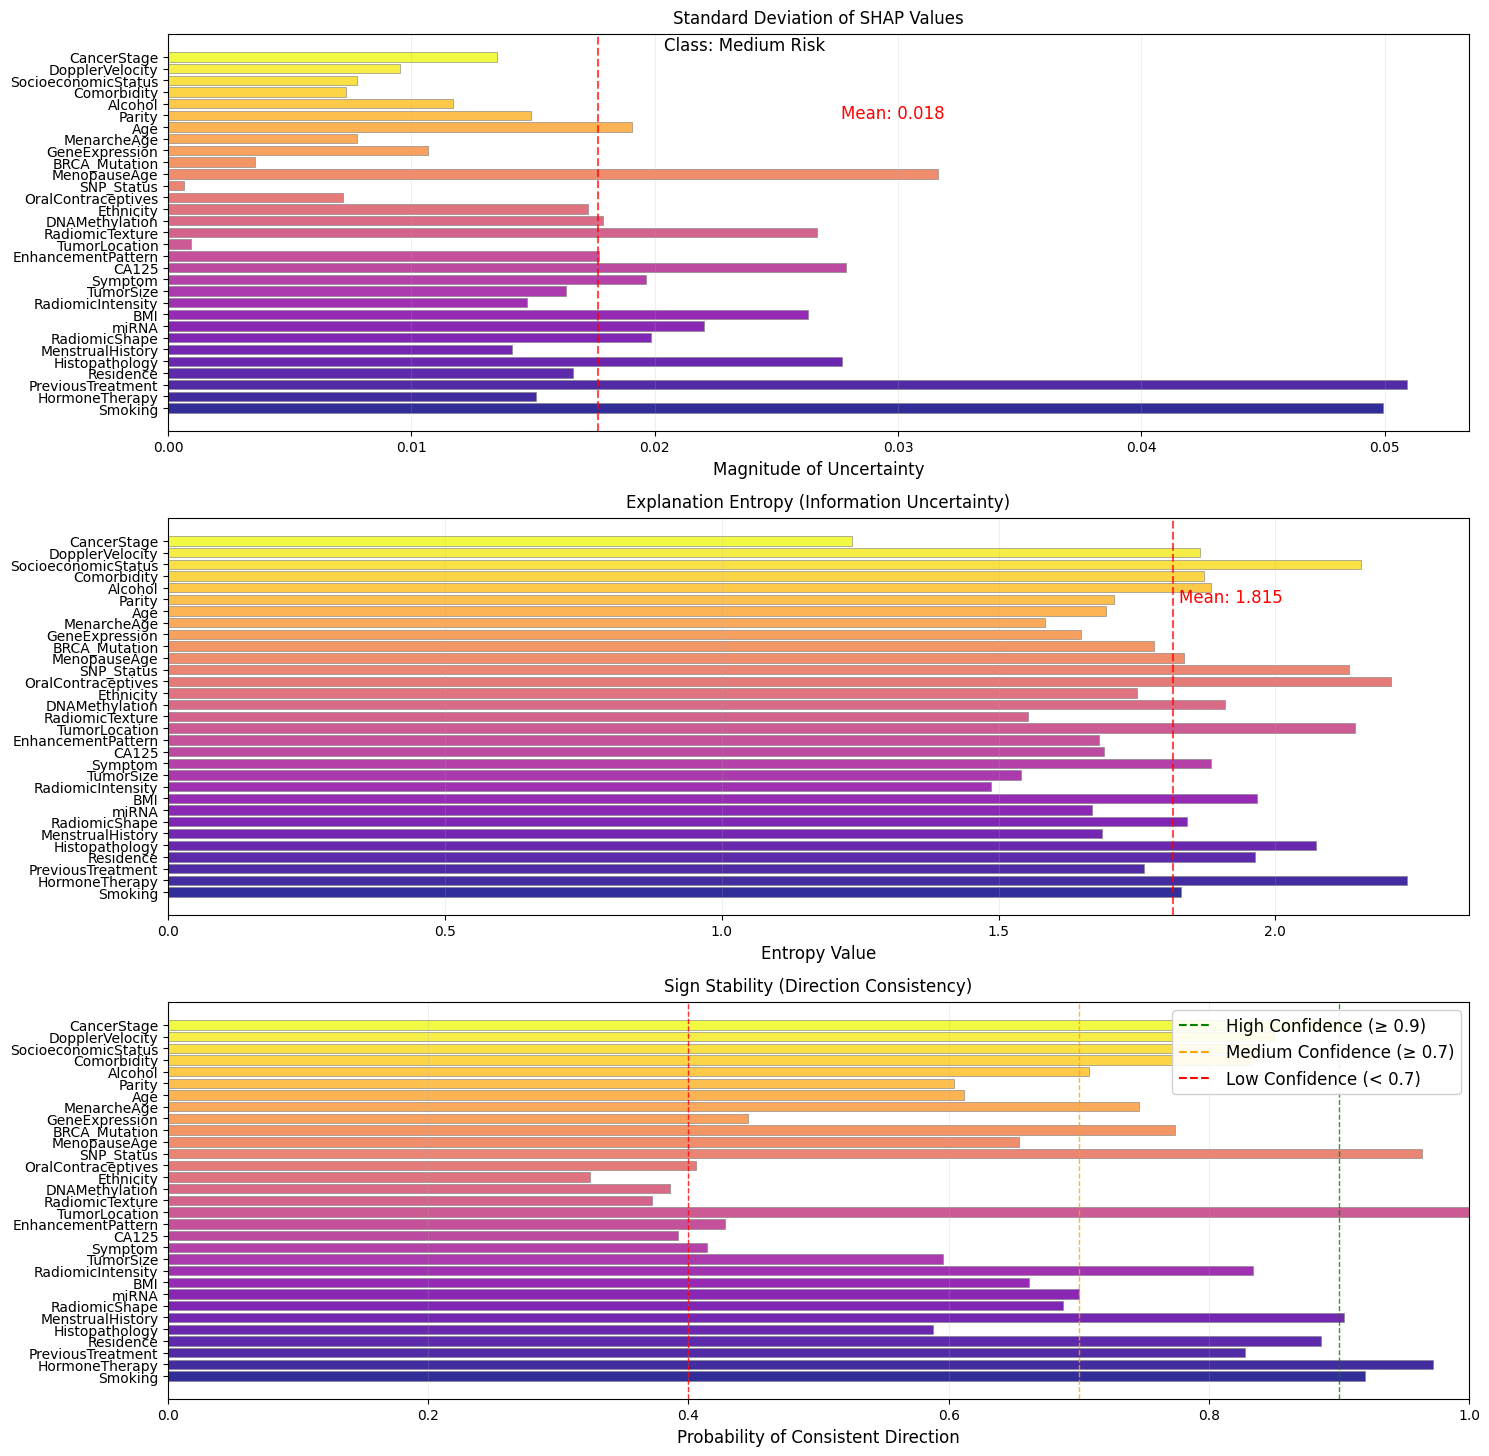


Explaining for class: High Risk


Sampling hypothesis space: 100%|██████████| 500/500 [12:43<00:00,  1.53s/it]


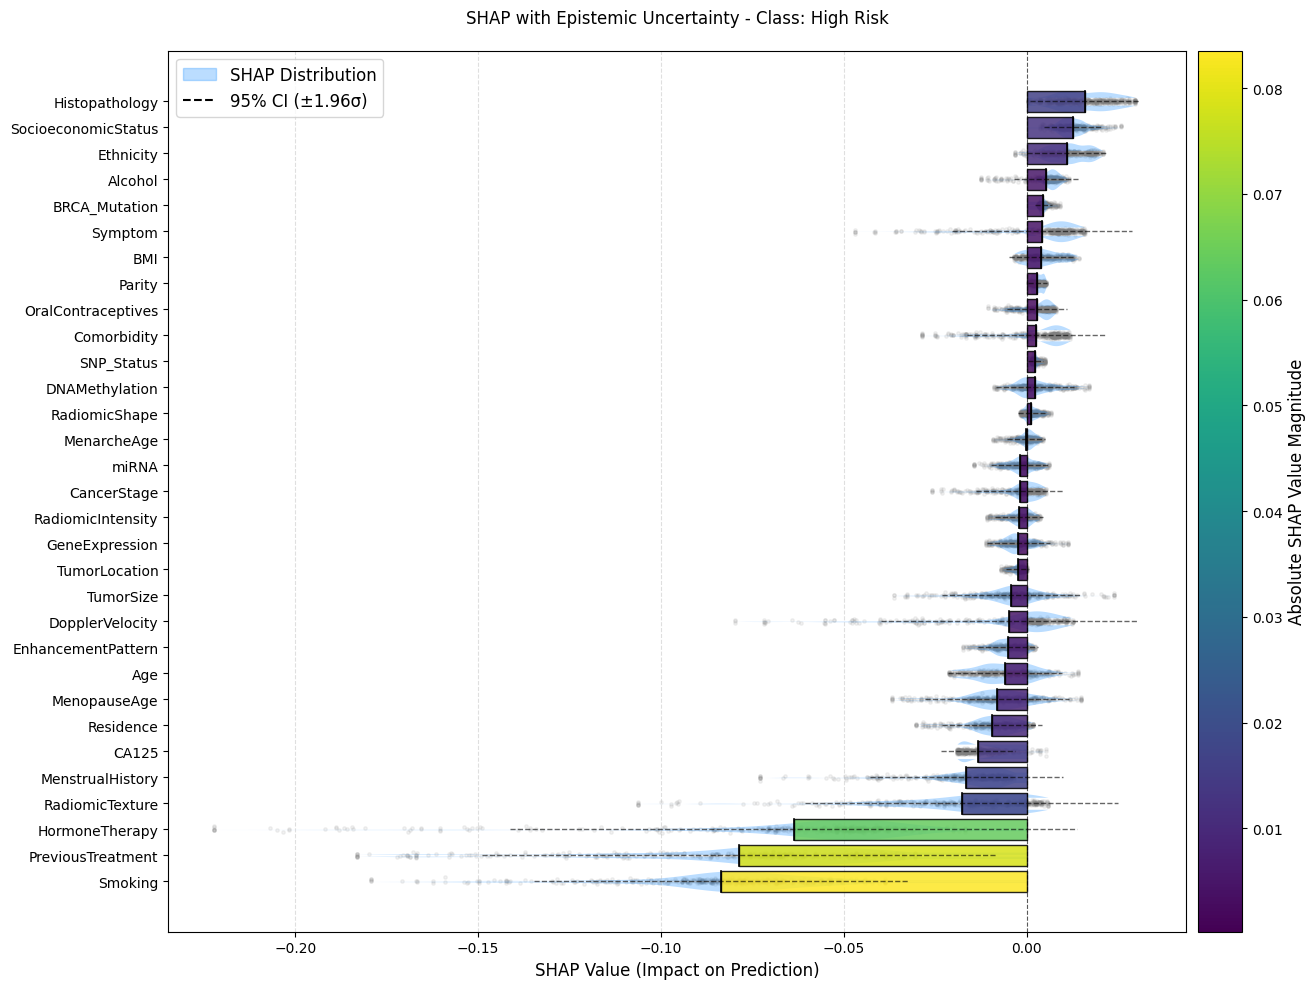

Top 5 indices: [ 8 22 28  7 10]


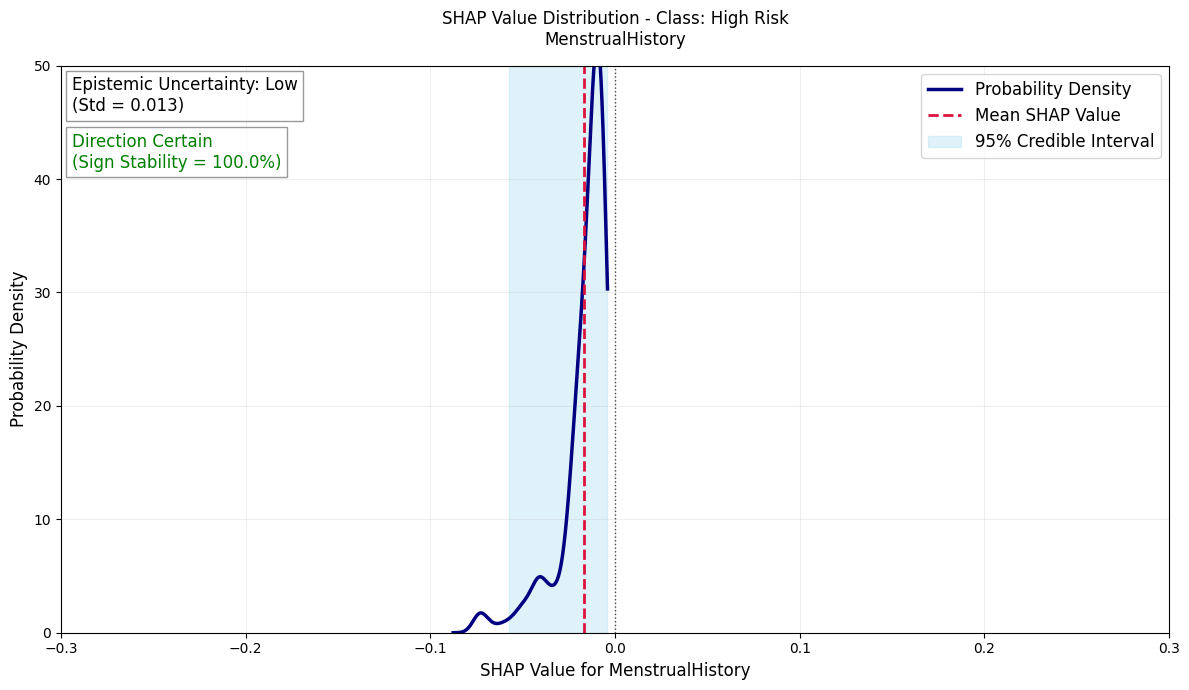

Top 5 indices: [ 8 22 28  7 10]


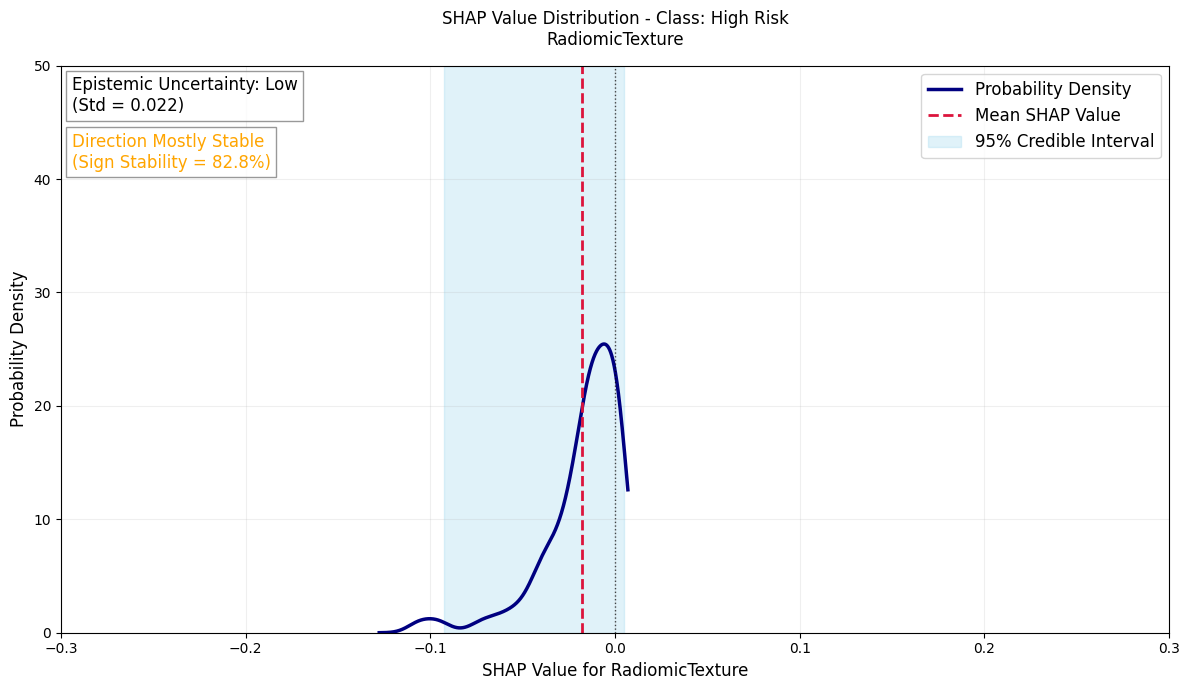

Top 5 indices: [ 8 22 28  7 10]


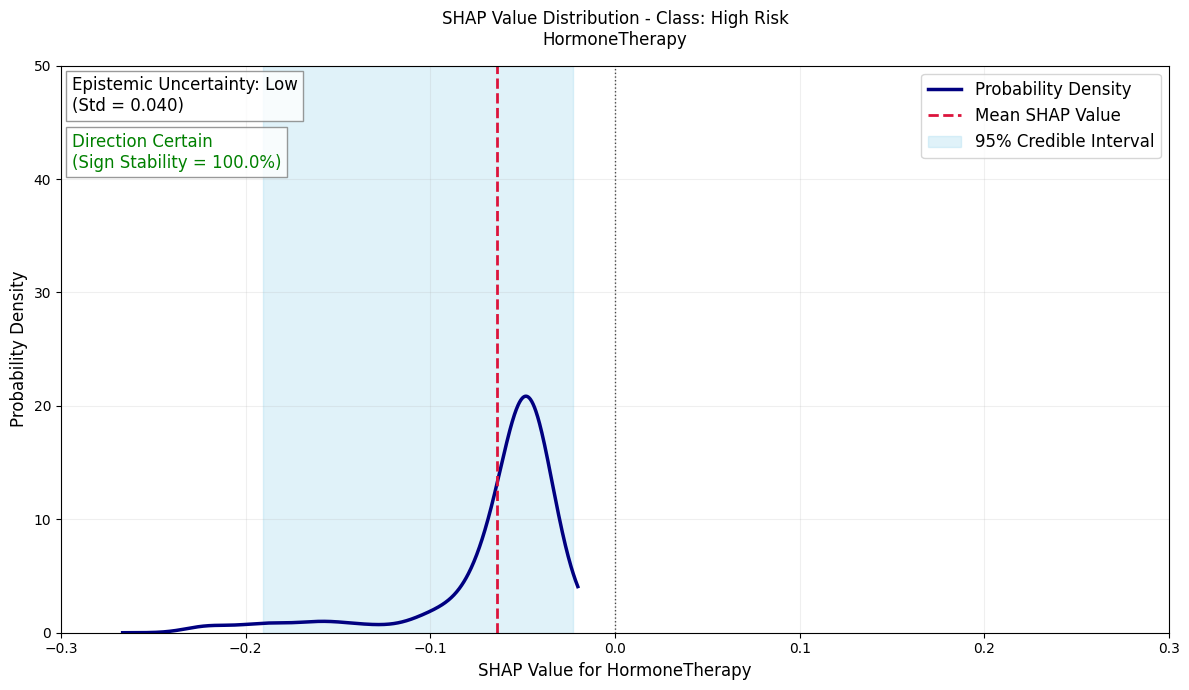

Top 5 indices: [ 8 22 28  7 10]


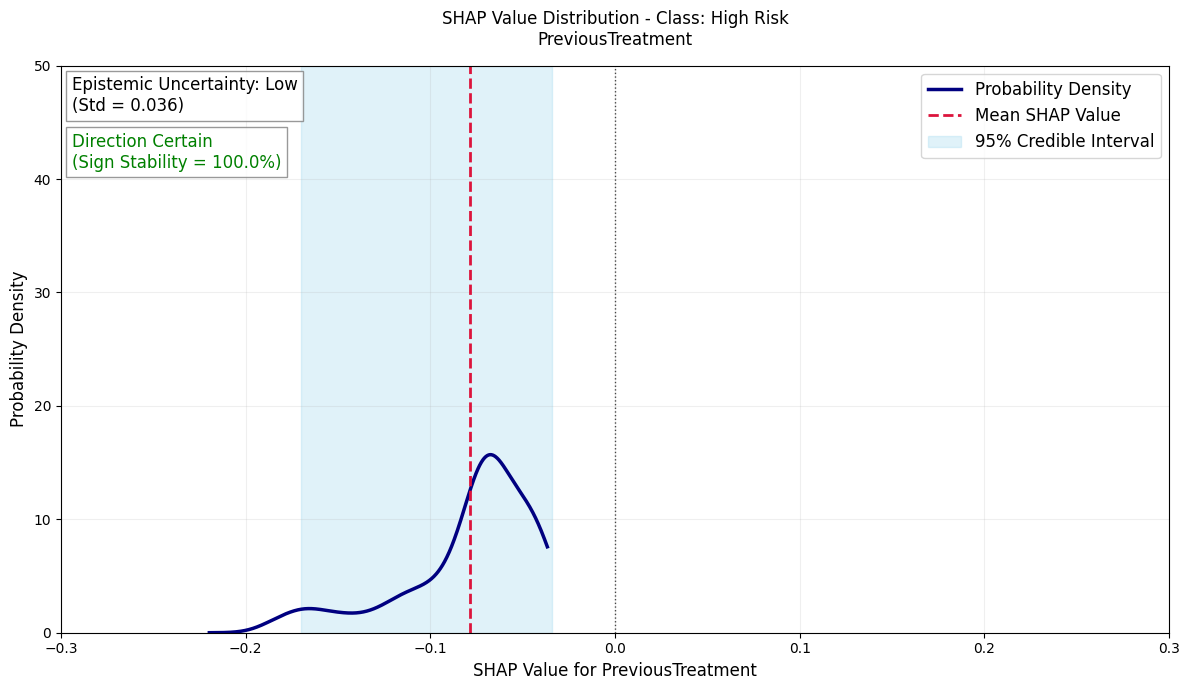

Top 5 indices: [ 8 22 28  7 10]


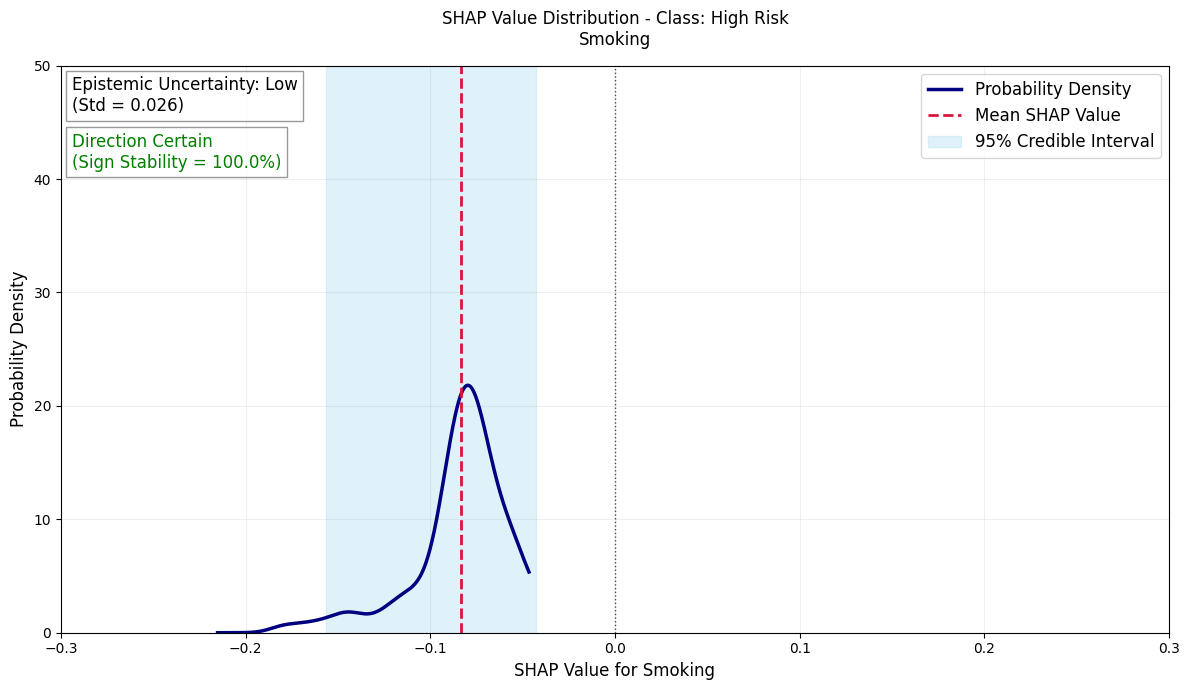

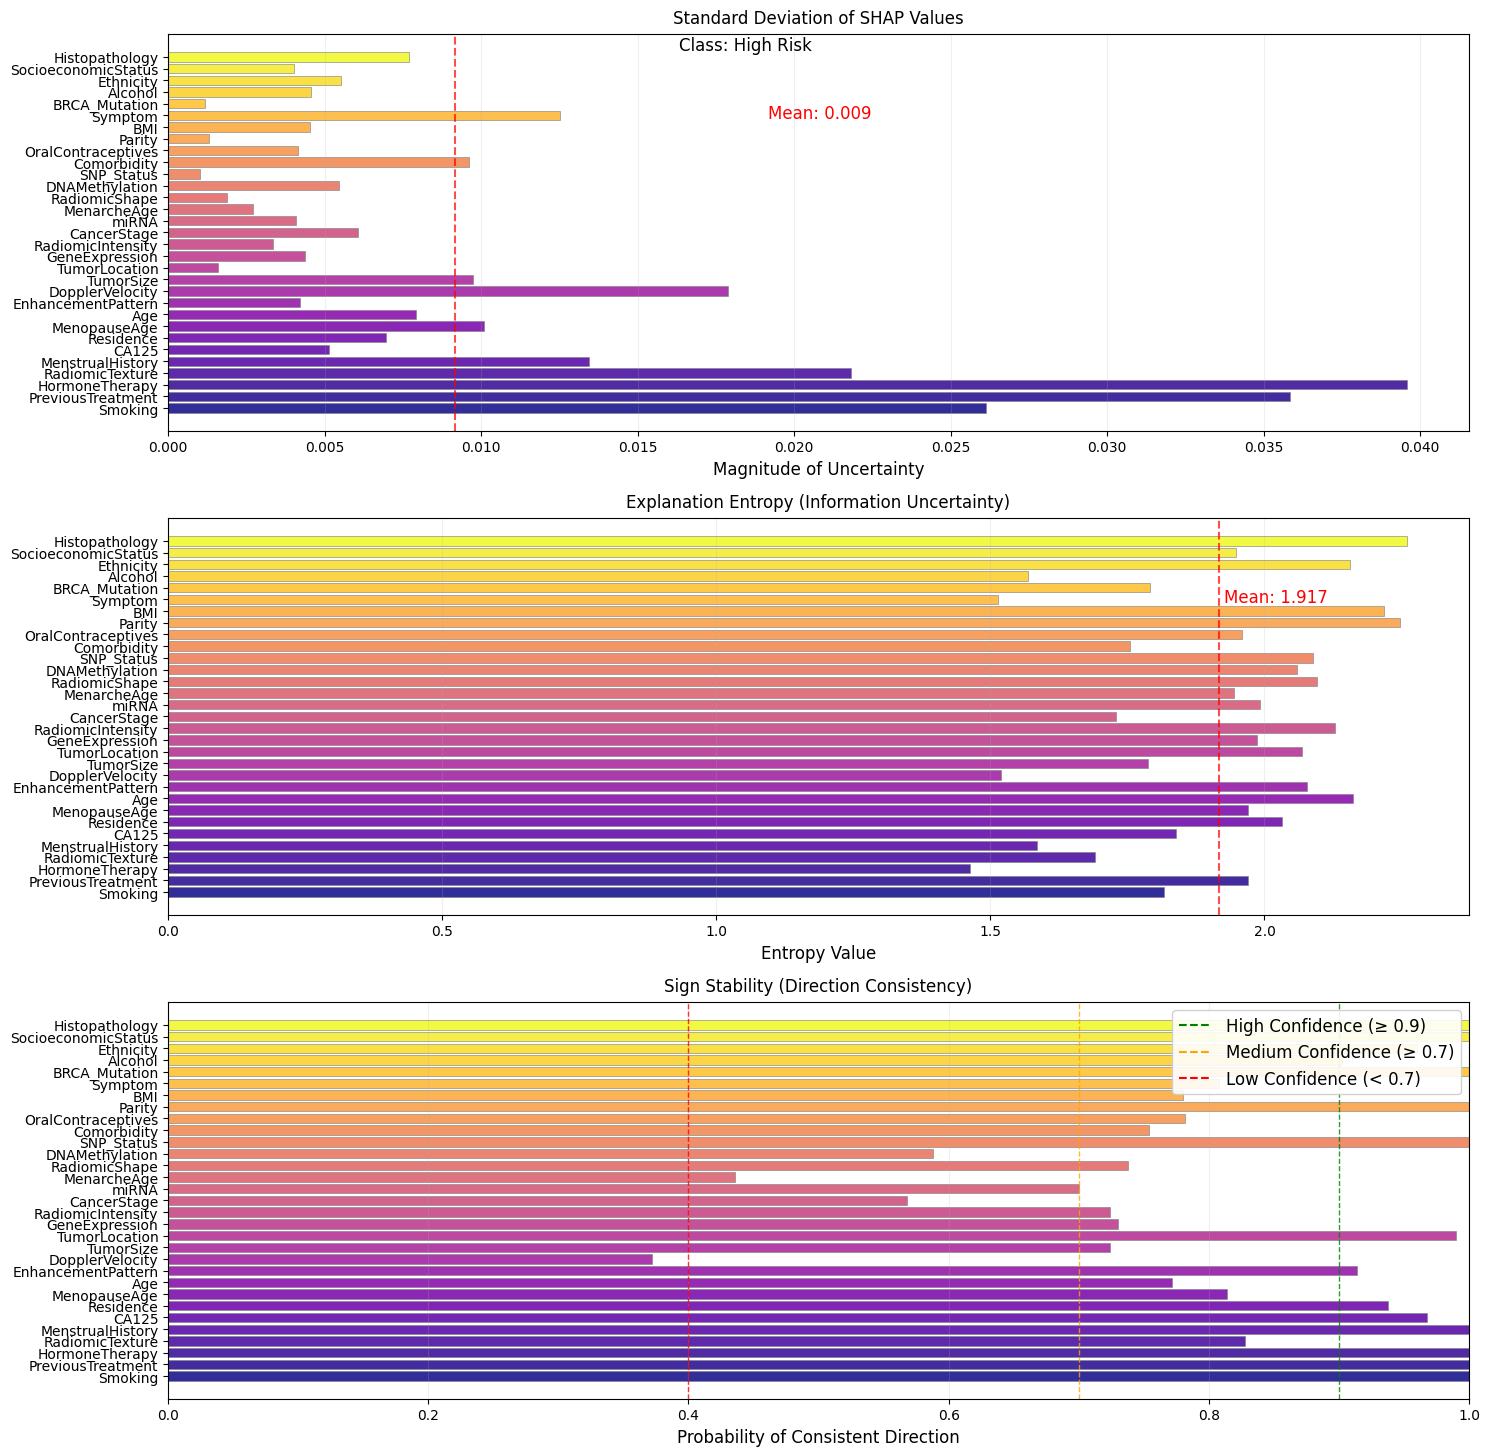

In [21]:
from UQEnTree import ExplainerClassification

explainer = ExplainerClassification(model, X_test, y_test, beta=3.0, random_state=42)

# Explain first instance for each class
instance = X_test[0:1]

for class_idx, class_name in enumerate(class_names):
    print(f"\nExplaining for class: {class_name}")
    results = explainer.explain(instance, class_idx=class_idx ,n_samples=500, alpha=1.0)
       # Plot results
    explainer.plot_uncertainty_bars(
        results, 
        feature_names,
        class_name=class_name
    )
    
    # Plot distribution for most important feature
    # most_important_feature = np.argmax(np.abs(results['mean']))
    # explainer.plot_uncertainty_distribution(
    #     results,
    #     feature_names,
    #     most_important_feature,
    #     class_name=class_name
    # )

    top5_indices = np.argsort(np.abs(results["mean"]))[-5:]
    for i in top5_indices:

        print("Top 5 indices:", top5_indices)
        explainer.plot_uncertainty_distribution(
            results,
            feature_names,
            i,
            class_name=class_name,
            ylim = (0,50),
            xlim = (-0.3,0.3)
        )
    
    
    explainer.plot_uncertainty_comparison(
        results,
        feature_names,
        class_name=class_name
    )
 